In [3]:
import MDAnalysis as mda
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import numpy as np
import math
import matplotlib.pyplot as plt
from tqdm import tqdm


script_dir = os.getcwd()

pdb_path = os.path.join(script_dir, '4Zn-8Ser pH', 'step4_pbcsetup.pdb')
dcd_path = os.path.join(script_dir, "Traj 4Zn-8Ser pH 1fs.dcd")

u = mda.Universe(pdb_path, dcd_path)

# This proves that the auto select for angles won't work
# The phi_selection() is reuturning None :(
for res in u.residues[0:8]:
    phi = res.phi_selection()
    if phi is None:
        names = None
    else:
        names = phi.names
    print('{}: {} '.format(res.resname, names))

print(u.residues[0])

# Really helpful visulizer https://proteopedia.org/w/Tutorial:Ramachandran_principle_and_phi_psi_angles

# C3 is alpha carbon, C2 is carboxyl carbon, only for our case
c_alpha = u.select_atoms('name C3')
c_carboxyl = u.select_atoms('name C2')
c_nitrogen = u.select_atoms('name N2')
carboxyl_meas = u.select_atoms('name C4') #For Phi
nitrogen_meas = u.select_atoms('name N1') #For Psi
phosphorus = u.select_atoms('name P')
o_carbonyl = u.select_atoms('name O6')

print(type(c_nitrogen.positions[0]))

print(type(c_alpha))
print(len(c_carboxyl))


LIG: None 
LIG: None 
LIG: None 
LIG: None 
LIG: None 
LIG: None 
LIG: None 
LIG: None 
<Residue LIG, 1>
<class 'numpy.ndarray'>
<class 'MDAnalysis.core.groups.AtomGroup'>
8


In [4]:
phi_x = []
psi_y = []
distances = []
zn_atoms = u.select_atoms("name ZN")

# TODO: Make into function, check for optimization.
for i in tqdm(range(0,8)):
    for frame in tqdm(u.trajectory[0:10001]):

        #coordination_distances = [(np.linalg.norm(zn.position - o_carbonyl.positions[i]), np.linalg.norm(zn.position - phosphorus.positions[i])) for zn in zn_atoms]
        #min_coordination_distance_squared = min([dist_pair[0]**2*dist_pair[1]**2 for dist_pair in coordination_distances])
        #distances.append(min_coordination_distance_squared)
        distances.append(np.linalg.norm(zn_atoms.positions - phosphorus.positions[i], axis=1).min())

        # Calculate the vectors needed for phi and psi dihedral angles for this frame
        alpha_nitro_vect = c_nitrogen.positions[i] - c_alpha.positions[i] #normal for phi, ref end for psi
        nitro_carbo_vect = carboxyl_meas.positions[i] - c_nitrogen.positions[i] #moving end phi
        alpha_carbo_vect = c_carboxyl.positions[i] - c_alpha.positions[i] #ref end phi, normal for psi
        carbo_nitro_vect = nitrogen_meas.positions[i] - c_carboxyl.positions[i] #moving end psi
            
        #Phi angles
        norm_moving_phi = nitro_carbo_vect - (np.dot(nitro_carbo_vect, alpha_nitro_vect))/((np.linalg.norm(alpha_nitro_vect)**2))*alpha_nitro_vect #Projection of nitro_carbo_vect onto the plane of alpha_nitro
        norm_ref_phi = alpha_carbo_vect - (np.dot(alpha_carbo_vect, alpha_nitro_vect))/((np.linalg.norm(alpha_nitro_vect)**2))*alpha_nitro_vect

        phi_value = np.dot(norm_moving_phi, norm_ref_phi)/(np.linalg.norm(norm_moving_phi)*np.linalg.norm(norm_ref_phi))
        phi_angle = math.acos(np.clip(phi_value,-1.0,1.0))*180/math.pi

        if np.cross(norm_moving_phi, norm_ref_phi)[0]/alpha_carbo_vect[0] < 0:
            phi_angle *= -1
        #Psi angles
        norm_moving_psi = carbo_nitro_vect - (np.dot(carbo_nitro_vect, alpha_carbo_vect))/((np.linalg.norm(alpha_carbo_vect)**2))*alpha_carbo_vect
        norm_ref_psi = alpha_nitro_vect - (np.dot(alpha_nitro_vect, alpha_carbo_vect))/((np.linalg.norm(alpha_carbo_vect)**2))*alpha_carbo_vect

        psi_value = np.dot(norm_moving_psi, norm_ref_psi)/(np.linalg.norm(norm_moving_psi)*np.linalg.norm(norm_ref_psi))
        psi_angle = math.acos(np.clip(psi_value,-1.0,1.0))*180/math.pi

        if np.cross(norm_moving_psi, norm_ref_psi)[0]/alpha_carbo_vect[0] > 0:
            psi_angle *= -1

        phi_x.append(phi_angle)
        psi_y.append(psi_angle)

100%|██████████| 8/8 [00:41<00:00,  5.16s/it]


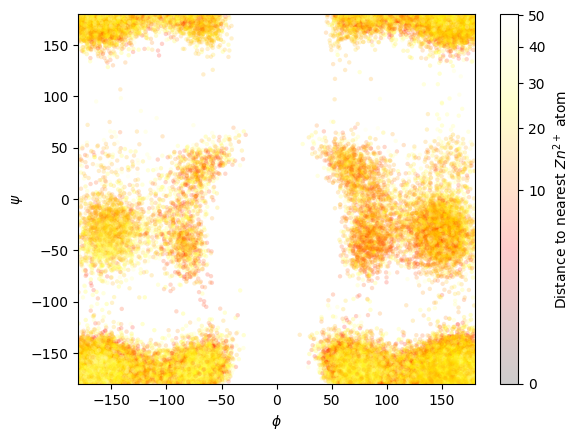

In [5]:
sc = plt.scatter(phi_x, psi_y, 
                 alpha=0.2, 
                 marker='o', 
                 sizes=[10 for _ in phi_x], 
                 c=distances, 
                 cmap='hot',
                 norm=mcolors.PowerNorm(gamma=0.4, vmin=0, vmax=max(distances)),
                 edgecolors='none')
plt.xlabel("$\\phi$")
plt.ylabel("$\\psi$")
plt.xlim(-180, 180)
plt.ylim(-180, 180)
plt.colorbar(sc, label="Distance to nearest $Zn^{2+}$ atom")
plt.show()